# Haldane, Triangular, and Kagome Lattices

**Model.** The Haldane model is a finite honeycomb single-particle Hamiltonian with complex next-nearest-neighbor hoppings. Triangular and kagome builders provide non-square tight-binding lattice geometries.

**Typical uses.** Finite topological-lattice spectra, graph-connectivity checks, flat-band and frustrated-lattice examples, and complex Hermitian matrix testbeds.

**Parameters.** `n_rows` and `n_cols` set the finite unit-cell dimensions $N_r$ and $N_c$; `t1` sets the Haldane nearest-neighbor hopping $t_1$; `t2` and `phi` set the complex next-nearest-neighbor hopping $t_2e^{\pm i\phi_H}$; `sublattice_potential` sets the sublattice potential $M$; and `hopping` sets the triangular or kagome nearest-neighbor coupling $t$.

**Useful plots.** Finite spectra and lattice graph visualizations using geometry helpers.

In [1]:
import matplotlib.pyplot as plt

from quantum_lattice_models.geometry import (
    honeycomb_lattice_positions,
    kagome_lattice_positions,
    triangular_lattice_positions,
)
from quantum_lattice_models.models import (
    haldane_honeycomb_lattice,
    kagome_lattice_tight_binding,
    triangular_lattice_tight_binding,
)
from quantum_lattice_models.plotting import plot_lattice_graph, plot_spectrum

In [2]:
H_haldane = haldane_honeycomb_lattice(
    n_rows=3, n_cols=3, t1=1.0, t2=0.18, phi=1.5707963267948966, sublattice_potential=0.1
)
H_triangular = triangular_lattice_tight_binding(n_rows=3, n_cols=3)
H_kagome = kagome_lattice_tight_binding(n_rows=2, n_cols=3)

rows = [
    ("Haldane", H_haldane.model_name, H_haldane.shape, "t1=1.00, t2=0.18, phi=pi/2, M=0.10"),
    ("Triangular", H_triangular.model_name, H_triangular.shape, "hopping=1.00"),
    ("Kagome", H_kagome.model_name, H_kagome.shape, "hopping=1.00"),
]
print("label      | builder                         | shape    | parameters")
print("---        | ---                             | ---      | ---")
for label, builder, shape, params in rows:
    print(f"{label:<10s} | {builder:<31s} | {str(shape):<8s} | {params}")

label      | builder                         | shape    | parameters
---        | ---                             | ---      | ---
Haldane    | haldane_honeycomb_lattice       | (18, 18) | t1=1.00, t2=0.18, phi=pi/2, M=0.10
Triangular | triangular_lattice_tight_binding | (9, 9)   | hopping=1.00
Kagome     | kagome_lattice_tight_binding    | (18, 18) | hopping=1.00


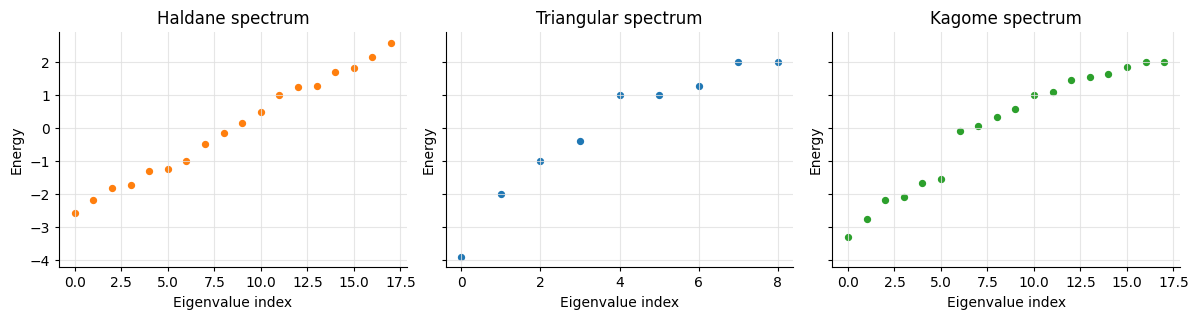

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.3), sharey=True)
plot_spectrum(H_haldane, ax=axes[0], s=18, color="tab:orange")
axes[0].set_title("Haldane spectrum")
plot_spectrum(H_triangular, ax=axes[1], s=18, color="tab:blue")
axes[1].set_title("Triangular spectrum")
plot_spectrum(H_kagome, ax=axes[2], s=18, color="tab:green")
axes[2].set_title("Kagome spectrum")
fig.tight_layout()

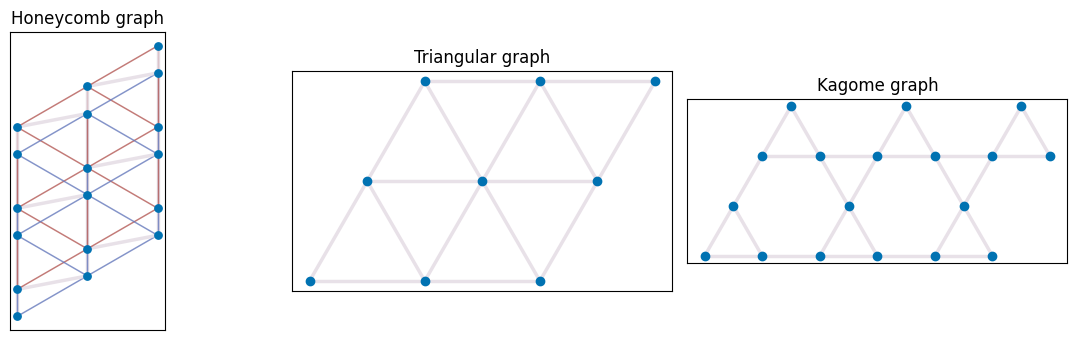

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
plot_lattice_graph(H_haldane, honeycomb_lattice_positions(3, 3), ax=axes[0], node_size=28)
axes[0].set_title("Honeycomb graph")
plot_lattice_graph(H_triangular, triangular_lattice_positions(3, 3), ax=axes[1], node_size=36)
axes[1].set_title("Triangular graph")
plot_lattice_graph(H_kagome, kagome_lattice_positions(2, 3), ax=axes[2], node_size=36)
axes[2].set_title("Kagome graph")
fig.tight_layout()